In [1]:
import pandas as pd
import numpy as np
import os, os.path
import seaborn as sns
import tqdm
import matplotlib.pyplot as plt

In [2]:
data_path = "spotify_data/"

files = os.listdir(data_path)

In [3]:
files

['pop.csv',
 'drum-and-bass.csv',
 'alt-rock.csv',
 'dubstep.csv',
 'hard-rock.csv',
 'r-n-b.csv',
 'reggaeton.csv',
 'emo.csv',
 'ska.csv',
 'kids.csv',
 'swedish.csv',
 'trance.csv',
 'punk.csv',
 'detroit-techno.csv',
 'hardstyle.csv',
 'j-idol.csv',
 'hip-hop.csv',
 'iranian.csv',
 'turkish.csv',
 'indie.csv',
 'rock-n-roll.csv',
 'rock.csv',
 'techno.csv',
 'bluegrass.csv',
 'acoustic.csv',
 'latino.csv',
 'electro.csv',
 'study.csv',
 'folk.csv',
 'club.csv',
 'mandopop.csv',
 'README.md',
 'classical.csv',
 'reggae.csv',
 'sleep.csv',
 'minimal-techno.csv',
 'pop-film.csv',
 'groove.csv',
 'progressive-house.csv',
 'rockabilly.csv',
 'show-tunes.csv',
 'songwriter.csv',
 'chill.csv',
 'metalcore.csv',
 'piano.csv',
 'deep-house.csv',
 'death-metal.csv',
 'hardcore.csv',
 'samba.csv',
 'breakbeat.csv',
 'comedy.csv',
 'edm.csv',
 'power-pop.csv',
 'children.csv',
 'world-music.csv',
 'afrobeat.csv',
 'dance.csv',
 'industrial.csv',
 'heavy-metal.csv',
 'house.csv',
 'trip-hop.csv

In [ ]:
print(files[0])
X = pd.read_csv(os.path.join(data_path, files[0]))
X.info()

pop.csv
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          1000 non-null   str    
 1   artists           1000 non-null   str    
 2   album_name        1000 non-null   str    
 3   track_name        1000 non-null   str    
 4   popularity        1000 non-null   int64  
 5   duration_ms       1000 non-null   int64  
 6   explicit          1000 non-null   bool   
 7   danceability      1000 non-null   float64
 8   energy            1000 non-null   float64
 9   key               1000 non-null   int64  
 10  loudness          1000 non-null   float64
 11  mode              1000 non-null   int64  
 12  speechiness       1000 non-null   float64
 13  acousticness      1000 non-null   float64
 14  instrumentalness  1000 non-null   float64
 15  liveness          1000 non-null   float64
 16  valence           1000 non-null   float64
 17 

In [5]:
X.head(2)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0VjIjW4GlUZAMYd2vXMi3b,The Weeknd,After Hours,Blinding Lights,91,200040,False,0.514,0.730,1,-5.934,1,0.0598,0.00146,0.000095,0.0897,0.334,171.005,4,pop
1,3yV2c3cYhkAwSsxAq6nRiv,Gajendra Verma,Table No. 21 (Original Motion Picture Soundtrack),Mann Mera,74,200120,False,0.535,0.765,1,-7.862,0,0.0444,0.05400,0.000000,0.0921,0.373,191.827,4,pop


# Analiza twórczości Eminema
Pytania badawcze:
- Wulgarność, a popularność: Czy utwory zawierające wulgaryzmy są bardziej popularne?
- Styl flow: Jak zmieniał się wskaźnik obecności mowy w albumach i utworach eminema na przestrzeni lat?
- Emocje: Jakie emocje dominują w tekstach Eminema i jak się one zmieniają w czasie?

In [ ]:
df_dict = {file: pd.read_csv(os.path.join(data_path, file)) for file in files}
df_dict.pop("README.md")

,**Źródło danych**
0,Maharshi Pandya. (2022). Spotify Tracks Datase...
1,Dane pierwotnie pozyskane z Spotify Web API
2,https://www.kaggle.com/datasets/maharshipandya...
3,Licencja: https://opendatacommons.org/licenses...


In [7]:
len(df_dict)

114

In [ ]:
spotify_df = pd.concat(df_dict.values(), ignore_index=True)
eminem_df = spotify_df[
    spotify_df["artists"].str.contains("Eminem", na=False, case=False)
]

In [ ]:
len(spotify_df)

32

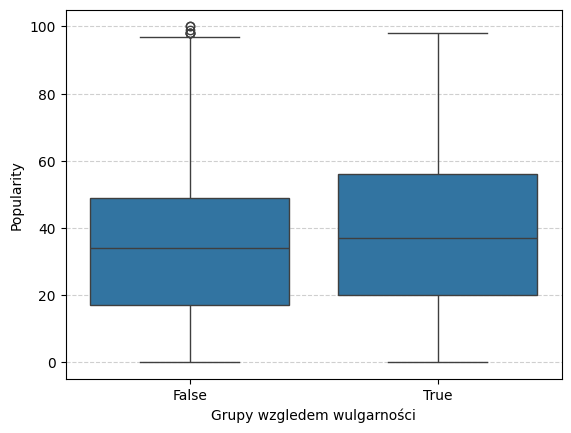

In [ ]:
ax = sns.boxplot(data=spotify_df, x="explicit", y="popularity")
counts = spotify_df["explicit"].value_counts()
for i, c in enumerate(counts):
    ax.text(i, spotify_df["popularity"].max() + 2, str(c), ha="center")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xlabel("Grupy wzgledem wulgarności")
plt.ylabel("Popularity")
plt.show()

In [19]:
spotify_df["explicit"]

0         False
1         False
2         False
3          True
4          True
          ...  
113995    False
113996    False
113997    False
113998     True
113999    False
Name: explicit, Length: 114000, dtype: bool